In [2]:
# 1. Explique brevemente cuál es el objetivo general del dataset TrashNet y qué tipo de problema de
# aprendizaje automático podría abordarse posteriormente con estos datos.

In [3]:
# 2. Inspeccione la estructura de carpetas del dataset e identifique las clases disponibles. ¿Cuántas
# categorías distintas existen y cuáles son?
import os
import pandas as pd
import matplotlib.pyplot as plt

# folders = os.listdir("../data")

path_to_dataset = "/Users/marcell/Documents/codigo_by_tecsup/datascience-g8/data/dataset-resized"

folders = sorted(os.listdir(path_to_dataset))
folders = [folder for folder in folders if folder != ".DS_Store"]

print(f"Categorias: {folders} | Total de categorias: {len(folders)}")

Categorias: ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash'] | Total de categorias: 6


In [14]:
# 3. Calcule el número total de imágenes presentes en el dataset. Compare el resultado con la cantidad
# reportada por la fuente original.

total_imagenes = 0
df = []

for folder in folders:
    path_to_categoria = path_to_dataset + "/" + folder
    imagenes = sorted(os.listdir(path_to_categoria))
    imagenes = [img for img in imagenes if img.endswith((".jpg", ".png"))]
    total_imagenes += len(imagenes)
    print(f"Categoria: {folder} - Total de muestras: {len(imagenes)}")

    df.append({
        "categoria": folder,
        "total_imagenes": len(imagenes)
    })

print(f"Total de imagenes: {total_imagenes}")

Categoria: cardboard - Total de muestras: 403
Categoria: glass - Total de muestras: 501
Categoria: metal - Total de muestras: 410
Categoria: paper - Total de muestras: 594
Categoria: plastic - Total de muestras: 482
Categoria: trash - Total de muestras: 137
Total de imagenes: 2527


In [5]:
# 4. Calcule la cantidad de imágenes por clase y presente los resultados en una tabla ordenada de mayor
# a menor frecuencia.
df = pd.DataFrame(df).sort_values("total_imagenes", ascending=False)
df.head(10)

,categoria,total_imagenes
3,paper,594
1,glass,501
4,plastic,482
2,metal,410
0,cardboard,403
5,trash,137


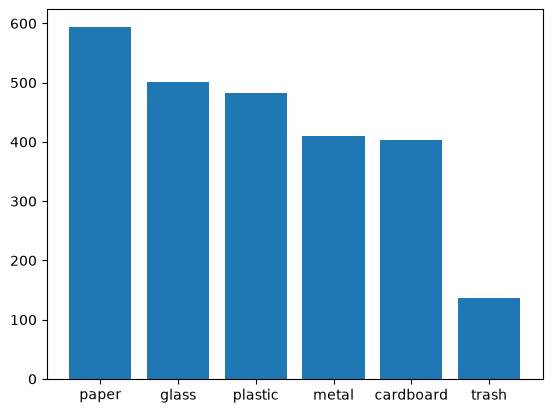

In [6]:
# 5. Visualice la distribución de imágenes por clase mediante un gráfico de barras. ¿El dataset está
# balanceado? Justifique su respuesta.
plt.bar(df["categoria"], df["total_imagenes"])
plt.show()

In [7]:
# 6. Calcule el porcentaje que representa cada clase respecto del total. Determine la clase mayoritaria, la
# minoritaria y la razón de desbalance entre ambas.
df["porcentaje"] = (df["total_imagenes"] / df["total_imagenes"].sum()) * 100

clase_mayoritaria = df["porcentaje"].idxmax()
clase_minoritaria = df["porcentaje"].idxmin()

clase_mayoritaria_tot_imgs = df.loc[clase_mayoritaria]["total_imagenes"]
clase_minoritaria_tot_imgs = df.loc[clase_minoritaria]["total_imagenes"]

razon = clase_mayoritaria_tot_imgs / clase_minoritaria_tot_imgs
print("Razon: ", razon)
df.head(10)

Razon:  4.335766423357664


,categoria,total_imagenes,porcentaje
3,paper,594,23.506134
1,glass,501,19.825880
4,plastic,482,19.074001
2,metal,410,16.224772
0,cardboard,403,15.947764
5,trash,137,5.421448


In [8]:
# 7. Verifique programáticamente que todas las imágenes puedan abrirse correctamente. ¿Existen
# archivos corruptos o ilegibles?

# uv add pillow -> instalar pillow
from PIL import Image
from pathlib import Path


all_images = []
clases = []
formatos = []
sizes_kb = []

for folder in folders:
    path_to_categoria = path_to_dataset + "/" + folder
    imagenes = sorted(os.listdir(path_to_categoria))
    formatos.extend([img.split(".")[-1] for img in imagenes])
    imagenes = [img for img in imagenes if img.endswith(".jpg")]
    rutas = [path_to_categoria + "/" + img for img in imagenes]
    sizes_kb.extend([Path(ruta).stat().st_size / 1024 for ruta in rutas])
    all_images.extend(rutas)
    clases.extend([folder] * len(rutas))

metadata_df = pd.DataFrame({
    "ruta": all_images,
    "clase": clases,
    "formato": formatos,
    "size_kb": sizes_kb
})

corruptos = []
for ruta_img in all_images:
    try:
        img = Image.open(ruta_img)
        img.verify()
    except:
        corruptos.append(ruta_img)

print(f"Archivos corruptos: {corruptos}")

Archivos corruptos: []


In [15]:
metadata_df

,ruta,clase,formato,size_kb
0,/Users/marcell/Documents/codigo_by_tecsup/data...,cardboard,jpg,16.926758
1,/Users/marcell/Documents/codigo_by_tecsup/data...,cardboard,jpg,21.174805
2,/Users/marcell/Documents/codigo_by_tecsup/data...,cardboard,jpg,14.535156
3,/Users/marcell/Documents/codigo_by_tecsup/data...,cardboard,jpg,13.954102
4,/Users/marcell/Documents/codigo_by_tecsup/data...,cardboard,jpg,17.592773
...,...,...,...,...
2522,/Users/marcell/Documents/codigo_by_tecsup/data...,trash,jpg,7.377930
2523,/Users/marcell/Documents/codigo_by_tecsup/data...,trash,jpg,16.273438
2524,/Users/marcell/Documents/codigo_by_tecsup/data...,trash,jpg,8.920898
2525,/Users/marcell/Documents/codigo_by_tecsup/data...,trash,jpg,14.216797


In [9]:
# 8. Identifique las extensiones o formatos de archivo presentes en el dataset y calcule su frecuencia.
metadata_df["formato"].value_counts()


formato
jpg    2527
Name: count, dtype: int64

In [10]:
# 9. Calcule el tamaño de cada archivo en kilobytes. Obtenga estadísticas descriptivas globales del
# tamaño de archivo y compárelas entre clases.
metadata_df["size_kb"].describe()

count    2527.000000
mean       16.726542
std         7.420650
min         5.472656
25%        11.628418
50%        15.024414
75%        19.827148
max        56.511719
Name: size_kb, dtype: float64

In [11]:
metadata_df

,ruta,clase,formato,size_kb
0,/Users/marcell/Documents/codigo_by_tecsup/data...,cardboard,jpg,16.926758
1,/Users/marcell/Documents/codigo_by_tecsup/data...,cardboard,jpg,21.174805
2,/Users/marcell/Documents/codigo_by_tecsup/data...,cardboard,jpg,14.535156
3,/Users/marcell/Documents/codigo_by_tecsup/data...,cardboard,jpg,13.954102
4,/Users/marcell/Documents/codigo_by_tecsup/data...,cardboard,jpg,17.592773
...,...,...,...,...
2522,/Users/marcell/Documents/codigo_by_tecsup/data...,trash,jpg,7.377930
2523,/Users/marcell/Documents/codigo_by_tecsup/data...,trash,jpg,16.273438
2524,/Users/marcell/Documents/codigo_by_tecsup/data...,trash,jpg,8.920898
2525,/Users/marcell/Documents/codigo_by_tecsup/data...,trash,jpg,14.216797


In [16]:
metadata_df.groupby("clase")["size_kb"].agg(["count", "mean", "median", "min", "max", "std"])

,count,mean,median,min,max,std
clase,,,,,,
cardboard,403,18.429552,18.474609,7.542969,34.099609,5.025402
glass,501,13.011202,12.446289,5.472656,33.013672,3.985900
metal,410,17.323576,16.184082,6.097656,49.162109,6.660452
paper,594,21.115726,17.900879,6.347656,56.511719,10.478928
plastic,482,14.072888,13.559082,5.847656,31.220703,4.705829
trash,137,13.822700,13.068359,6.375000,35.428711,4.590329


In [ ]:
# 10. Extraiga el ancho y alto de todas las imágenes. Determine cuántas resoluciones diferentes existen y
# cuáles son las más frecuentes.
anchos = []
altos = []
for path_img in metadata_df["ruta"]:
    img = Image.open(path_img)
    ancho, alto = img.size
    anchos.append(ancho)
    altos.append(alto)

metadata_df["dim_ancho"] = anchos
metadata_df["dim_alto"] = altos

(metadata_df["dim_ancho"].astype(str) + " x " + metadata_df["dim_alto"].astype(str)).value_counts()

512 x 384    2527
Name: count, dtype: int64

In [26]:
# 11. Calcule la relación de aspecto (ancho/alto) de cada imagen. ¿La relación de aspecto es uniforme o
# existen imágenes atípicas?
metadata_df["ratio_aspecto"] = metadata_df["dim_ancho"] / metadata_df["dim_alto"]
metadata_df["ratio_aspecto"].value_counts()

ratio_aspecto
1.333333    2527
Name: count, dtype: int64

In [29]:
# 12. Identifique el modo o número de canales de las imágenes (por ejemplo, RGB, escala de grises).
# ¿Todas tienen la misma estructura de canales?

num_canales = []
for path_img in metadata_df["ruta"]:
    img = Image.open(path_img)
    mode = img.mode
    num_canales.append(mode)

metadata_df["num_canales"] = num_canales
metadata_df.head(10)

metadata_df["num_canales"].value_counts()

num_canales
RGB    2527
Name: count, dtype: int64

In [30]:
metadata_df

,ruta,clase,formato,size_kb,dim_ancho,dim_alto,ratio_aspecto,num_canales
0,/Users/marcell/Documents/codigo_by_tecsup/data...,cardboard,jpg,16.926758,512,384,1.333333,RGB
1,/Users/marcell/Documents/codigo_by_tecsup/data...,cardboard,jpg,21.174805,512,384,1.333333,RGB
2,/Users/marcell/Documents/codigo_by_tecsup/data...,cardboard,jpg,14.535156,512,384,1.333333,RGB
3,/Users/marcell/Documents/codigo_by_tecsup/data...,cardboard,jpg,13.954102,512,384,1.333333,RGB
4,/Users/marcell/Documents/codigo_by_tecsup/data...,cardboard,jpg,17.592773,512,384,1.333333,RGB
...,...,...,...,...,...,...,...,...
2522,/Users/marcell/Documents/codigo_by_tecsup/data...,trash,jpg,7.377930,512,384,1.333333,RGB
2523,/Users/marcell/Documents/codigo_by_tecsup/data...,trash,jpg,16.273438,512,384,1.333333,RGB
2524,/Users/marcell/Documents/codigo_by_tecsup/data...,trash,jpg,8.920898,512,384,1.333333,RGB
2525,/Users/marcell/Documents/codigo_by_tecsup/data...,trash,jpg,14.216797,512,384,1.333333,RGB


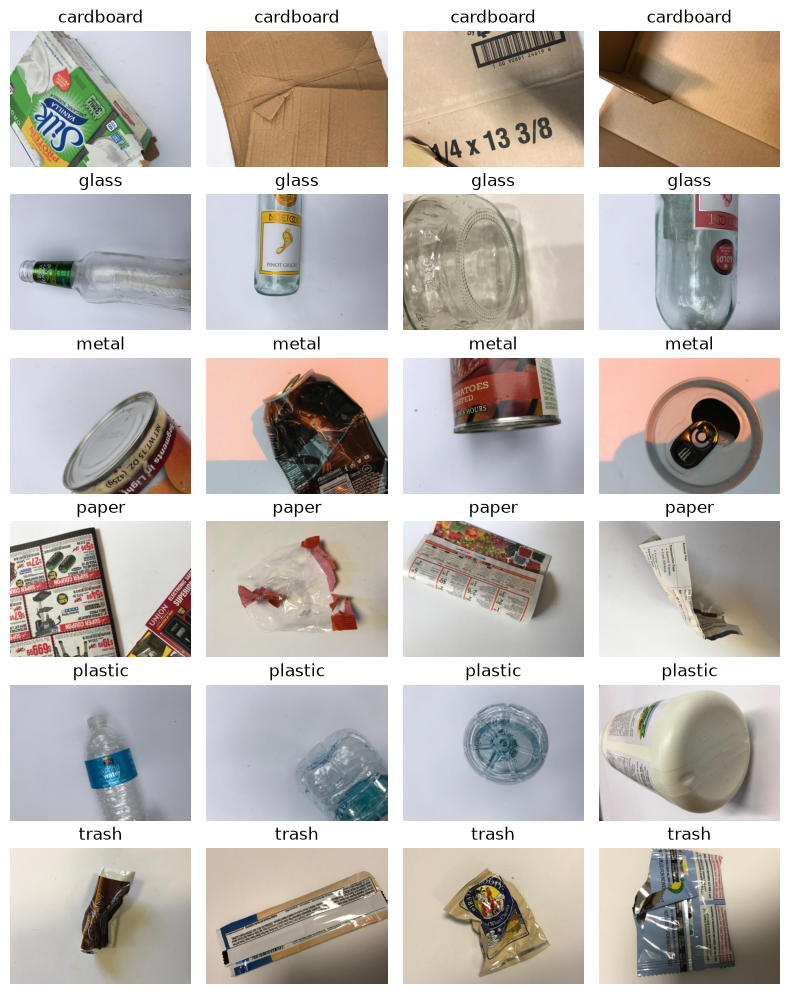

In [59]:
# 13. Muestre una cuadrícula con varias imágenes aleatorias de cada clase. Describa visualmente qué
# características parecen diferenciar unas categorías de otras.
import random

def show_imagenes_random(dataframe, n_imgs_per_class=4, seed=42):
    random.seed(seed)
    clases_unicas = sorted(dataframe["clase"].unique())
    paths = []
    class_labels = []
    for clase_unica in clases_unicas:
        paths.append(
            random.sample(metadata_df[metadata_df["clase"] == clase_unica]["ruta"].to_list(), 4)
        )
        class_labels.append([clase_unica] * n_imgs_per_class)

    fig, axes = plt.subplots(
        len(clases_unicas),
        n_imgs_per_class,
        figsize=(8, 10)
    )

    for row, (path, class_label) in enumerate(zip(paths, class_labels)):
        for col, (p, cl) in enumerate(zip(path, class_label)):
            # print(row, col, p)
            img = Image.open(p)
            axes[row, col].imshow(img)
            axes[row, col].set_title(cl)
            axes[row, col].axis("off")

    plt.tight_layout()
    plt.show()


show_imagenes_random(metadata_df, seed=100)

In [70]:
# 14. Calcule el valor medio de los canales R, G y B para cada imagen y obtenga posteriormente el
# promedio de estos valores por clase.
import numpy as np

mean_r = []
mean_g = []
mean_b = []
for path_img in metadata_df["ruta"]:
    img = np.array(Image.open(path_img))
    mean_r.append(img[:, :, 0].mean())
    mean_g.append(img[:, :, 1].mean())
    mean_b.append(img[:, :, 2].mean())

metadata_df["mean_r"] = mean_r
metadata_df["mean_g"] = mean_g
metadata_df["mean_b"] = mean_b

metadata_df.groupby("clase")[["mean_r", "mean_g", "mean_b"]].mean()

,mean_r,mean_g,mean_b
clase,,,
cardboard,170.080264,148.857001,127.931290
glass,176.375375,170.518422,163.098047
metal,164.828272,157.005761,151.896572
paper,172.181150,164.551183,155.431459
plastic,171.084918,170.091793,168.978540
trash,178.804079,166.113023,149.045881


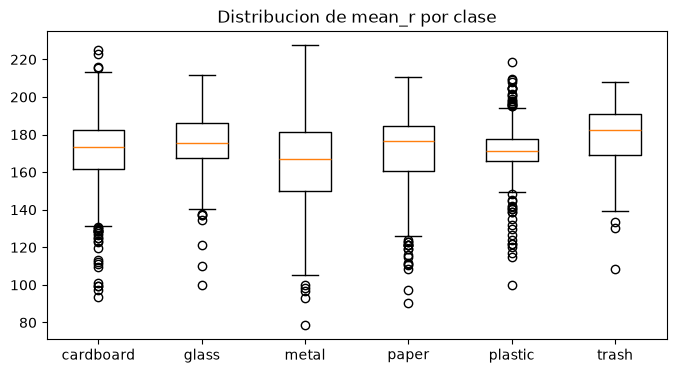

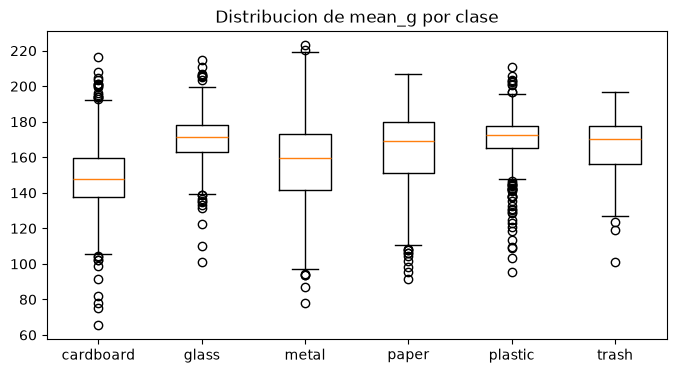

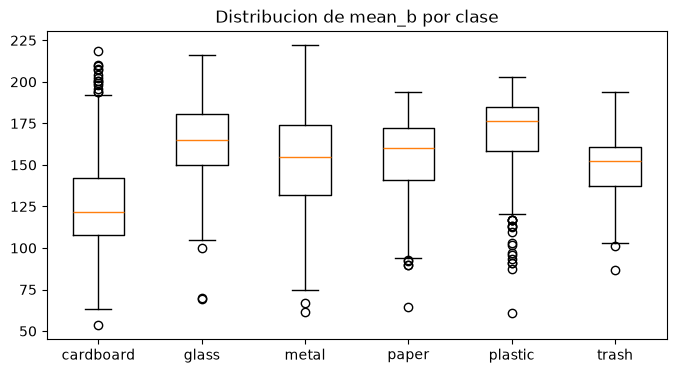

In [72]:
# 15. Compare mediante gráficos la distribución de la intensidad media de los canales R, G y B entre las
# seis clases. ¿Se observan diferencias apreciables?

for canal in ["mean_r", "mean_g", "mean_b"]:
    plt.figure(figsize=(8, 4))
    grupos = [
        metadata_df.loc[metadata_df["clase"] == clase, canal].values
        for clase in metadata_df["clase"].unique()
    ]

    plt.boxplot(grupos, tick_labels=metadata_df["clase"].unique())
    plt.title(f"Distribucion de {canal} por clase")
    plt.show()

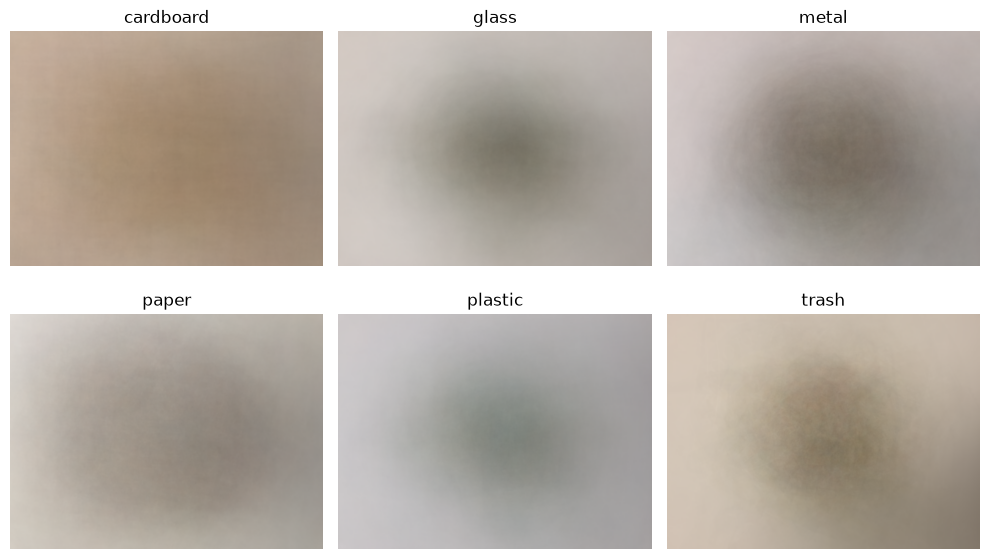

In [78]:
# 16. Construya una imagen promedio para cada clase. ¿Qué información aporta una imagen promedio y
# qué patrones generales pueden observarse?

def mean_image(paths, size=(384, 512, 3)):
    acc = np.zeros(size)
    for path in paths:
        img = np.array(Image.open(path))
        acc += img

    return np.clip(acc / len(paths), 0, 255).astype(np.uint8)

fig, axes = plt.subplots(2, 3, figsize=(10,6))

for clase, ax in zip(metadata_df["clase"].unique(), axes.ravel()):
    avg = mean_image(metadata_df[metadata_df["clase"] == clase]["ruta"])
    ax.imshow(avg)
    ax.set_title(clase)
    ax.axis("off")

plt.tight_layout()
plt.show()

In [89]:
# 17. Convierta las imágenes a escala de grises y calcule el brillo medio de cada imagen. Obtenga
# estadísticas descriptivas del brillo para todo el dataset.

brillo = []
for path_img in metadata_df["ruta"]:
    img = np.array(Image.open(path_img).convert("L"))
    brillo.append(img.mean())

metadata_df["brillo"] = brillo

metadata_df["brillo"].describe()

count    2527.000000
mean      164.685113
std        19.997390
min        77.998515
25%       153.609304
50%       168.407455
75%       177.697617
max       224.416036
Name: brillo, dtype: float64

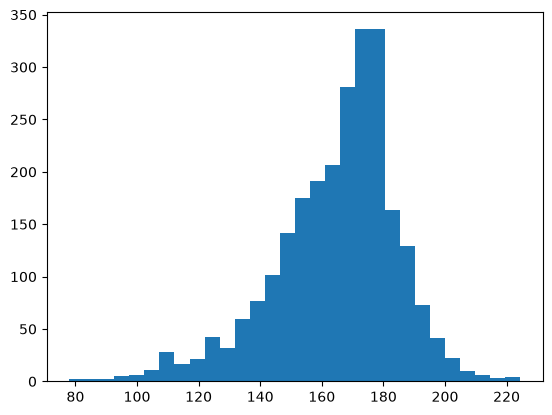

In [90]:
plt.hist(metadata_df["brillo"], bins=30)
plt.show()

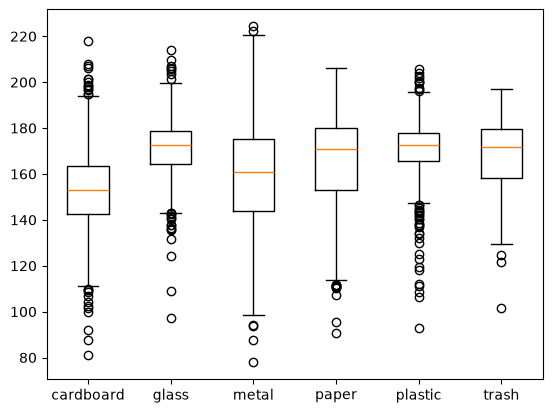

In [93]:
# 18. Compare la distribución del brillo entre clases mediante boxplots. ¿Qué clases presentan imágenes
# relativamente más claras u oscuras?

grupos = [
    metadata_df.loc[metadata_df["clase"] == clase, "brillo"].values
    for clase in metadata_df["clase"].unique()
]

plt.boxplot(grupos, tick_labels=metadata_df["clase"].unique())
plt.show()

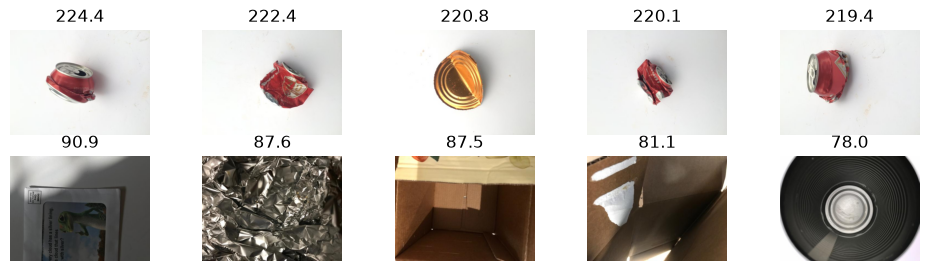

In [105]:
# 19. Identifique y visualice las cinco imágenes más oscuras y las cinco más claras del dataset según el
# brillo medio calculado.
mas_claras = metadata_df.sort_values("brillo", ascending=False).head(5)["ruta"].to_list()
mas_oscuras = metadata_df.sort_values("brillo", ascending=False).tail(5)["ruta"].to_list()

brillo_claras = metadata_df.sort_values("brillo", ascending=False).head(5)["brillo"].to_list()
brillo_oscuras = metadata_df.sort_values("brillo", ascending=False).tail(5)["brillo"].to_list()

imgs = mas_claras + mas_oscuras
brillos = brillo_claras + brillo_oscuras

fig, axes = plt.subplots(2, 5, figsize=(12, 3))
for ax, (img, brillo) in zip(axes.ravel(), zip(imgs, brillos)):
    img = Image.open(img)
    ax.imshow(img)
    ax.set_title(f"{brillo:.1f}")
    ax.axis("off")

plt.show()

In [106]:
# 20. Calcule una medida de contraste para cada imagen utilizando la desviación estándar de las
# intensidades en escala de grises.

contraste = []
for path_img in metadata_df["ruta"]:
    img = np.array(Image.open(path_img).convert("L"))
    contraste.append(img.std())

metadata_df["contraste"] = contraste

metadata_df["contraste"].describe()

count    2527.000000
mean       46.360759
std        15.501021
min         7.494097
25%        34.922321
50%        45.044002
75%        57.453953
max        98.731349
Name: contraste, dtype: float64

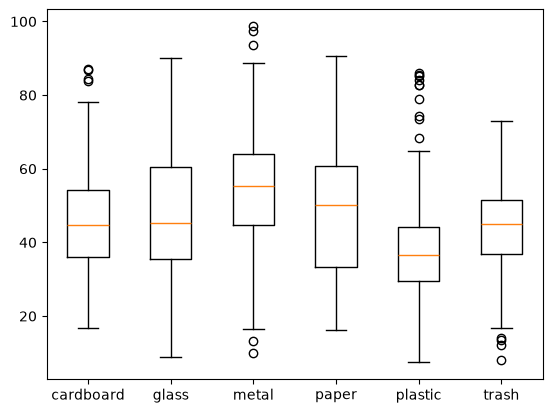

In [107]:
# 21. Compare el contraste entre las distintas clases. Identifique las clases con mayor y menor contraste
# mediano.
grupos = [
    metadata_df.loc[metadata_df["clase"] == clase, "contraste"].values
    for clase in metadata_df["clase"].unique()
]

plt.boxplot(grupos, tick_labels=metadata_df["clase"].unique())
plt.show()

In [112]:
# 22. Convierta las imágenes al espacio HSV y calcule la saturación media. Analice si determinadas
# clases presentan colores más intensos que otras.

saturacion = []
for path_img in metadata_df["ruta"]:
    img = np.array(Image.open(path_img).convert("HSV"))
    saturacion.append(img[:,:,1].mean())

metadata_df["saturacion"] = saturacion

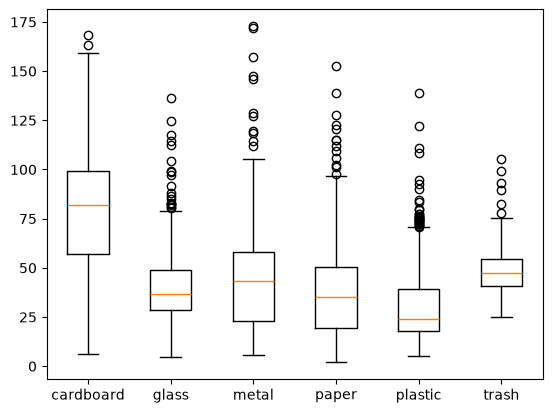

In [115]:
grupos = [
    metadata_df.loc[metadata_df["clase"] == clase, "saturacion"].values
    for clase in metadata_df["clase"].unique()
]

plt.boxplot(grupos, tick_labels=metadata_df["clase"].unique())
plt.show()

In [ ]:

# 23. Seleccione imágenes representativas de al menos tres clases y construya histogramas de intensidad
# para sus canales RGB. Explique cómo interpretar estos histogramas.
# D. Complejidad visual, duplicados y outliers
# 24. Calcule una medida sencilla de complejidad visual basada en cambios o bordes de intensidad.
# Compare esta medida entre las clases.
# 25. Calcule la entropía de intensidad de cada imagen. ¿Qué representa esta métrica y qué clases
# muestran mayor entropía mediana?
# 26. Busque archivos exactamente duplicados utilizando un hash criptográfico (por ejemplo, MD5).
# ¿Existen imágenes con contenido binario idéntico?
# 27. Implemente un hash perceptual sencillo (average hash) para buscar imágenes visualmente idénticas
# o muy similares. Visualice algunos grupos candidatos si existen.
# 28. Utilice el método IQR sobre variables derivadas de las imágenes (brillo, contraste, saturación,
# entropía y complejidad visual) para identificar posibles outliers. ¿Cuántas imágenes son marcadas como
# atípicas?
# 29. Construya una matriz de correlación entre las características numéricas extraídas de las imágenes.
# Analice las relaciones más relevantes y explique por qué algunas características podrían estar
# asociadas.
# Práctica EDA de imágenes — TrashNet | Página 2
# E. Síntesis del EDA
# 30. A partir de todos los resultados obtenidos, redacte al menos cinco conclusiones del EDA y proponga
# decisiones de preprocesamiento que deberían considerarse antes de entrenar un modelo de
# clasificación de imágenes con TrashNet.
# Práctica ED